## Notebook 4. Time Series Analysis

After finishing the EDA I realized just looking at charts wasn't 
enough to really understand what's happening with these commodity 
prices. I wanted to go deeper. So in this notebook I used proper 
statistical tools to uncover the hidden structure inside 33 years 
of coal and nickel data. Things like whether there's a real trend 
or just noise, whether history repeats itself in a predictable way, 
and how many months back I need to look to make a reliable forecast. 
These are the questions I wanted to answer before building any model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/commodity_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

print(f"Loaded: {df.shape[0]} rows")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Loaded: 401 rows
Date range: 1993-01-01 00:00:00 to 2026-05-01 00:00:00


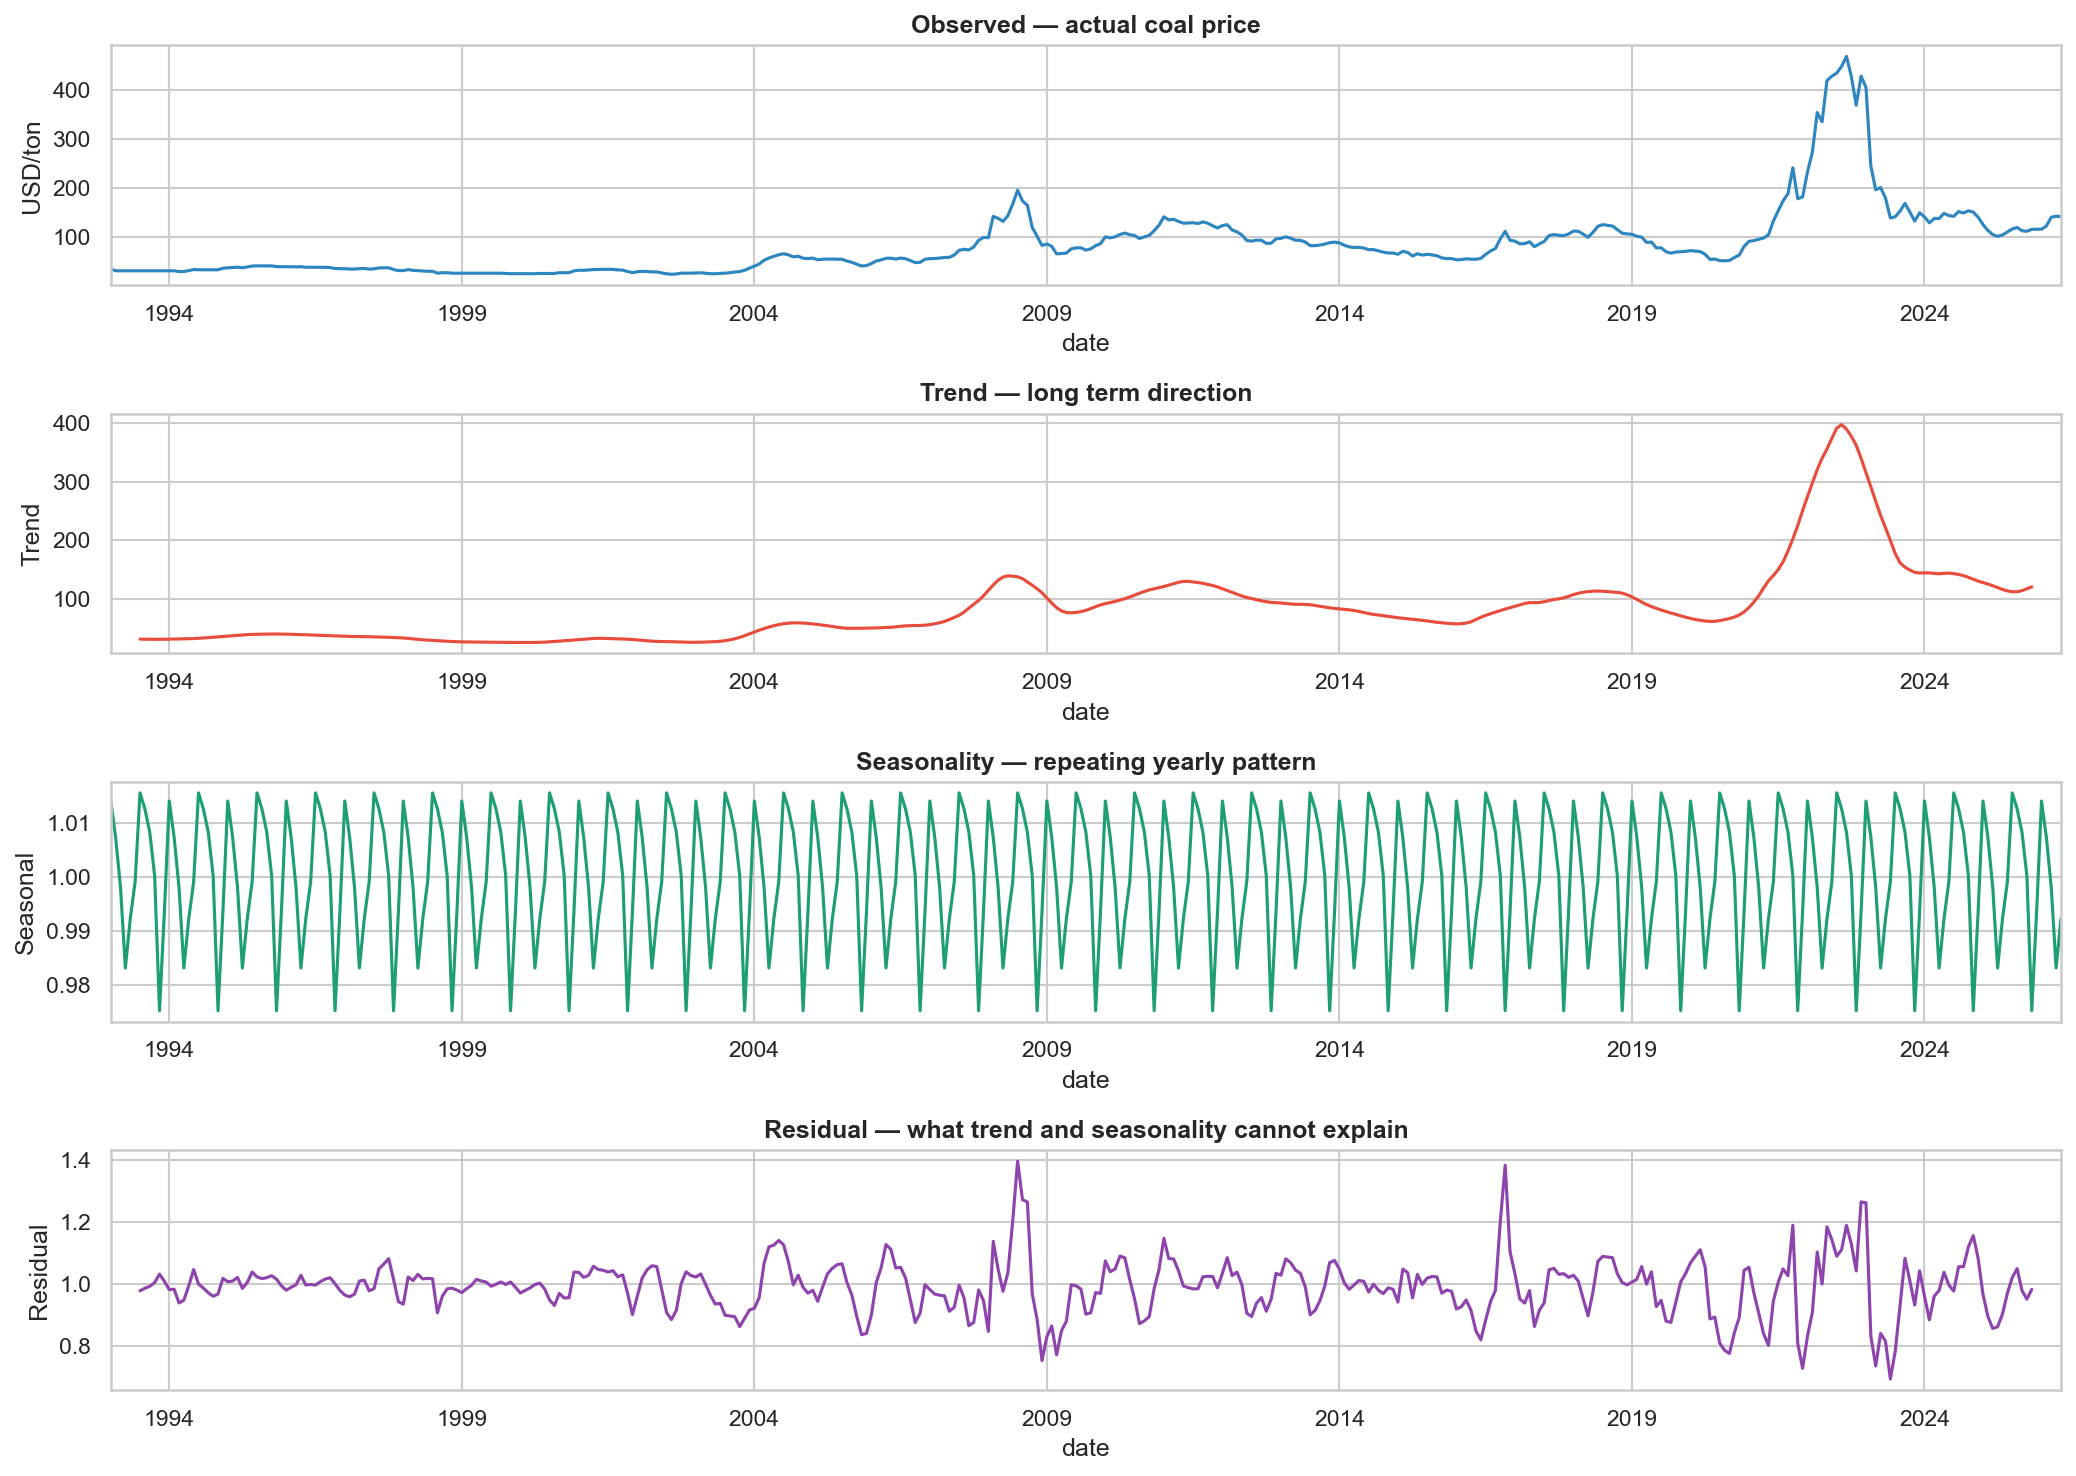

Chart 7 saved


In [2]:
# Seasonal decomposition - breaks price into 3 components
coal_decomp = seasonal_decompose(df['coal_price_usd'], 
                                  model='multiplicative', 
                                  period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

coal_decomp.observed.plot(ax=axes[0], color='#2E86C1')
axes[0].set_title('Observed — actual coal price', fontweight='bold')
axes[0].set_ylabel('USD/ton')

coal_decomp.trend.plot(ax=axes[1], color='#E74C3C')
axes[1].set_title('Trend — long term direction', fontweight='bold')
axes[1].set_ylabel('Trend')

coal_decomp.seasonal.plot(ax=axes[2], color='#1D9E75')
axes[2].set_title('Seasonality — repeating yearly pattern', fontweight='bold')
axes[2].set_ylabel('Seasonal')

coal_decomp.resid.plot(ax=axes[3], color='#8E44AD')
axes[3].set_title('Residual — what trend and seasonality cannot explain', fontweight='bold')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('../charts/07_coal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

## Coal Price Decomposition Breaking Down 33 Years of Price Movement

So this chart is basically taking the coal price and ripping it apart 
into 3 separate pieces to understand what's really driving it.

**The Trend** tells us the big picture and the story is clear. 
Coal has been on a long upward journey since 1993. It's not a straight 
line, there are bumps and crashes along the way, but the overall 
direction is up. For Indonesia as the world's top coal exporter, 
this is fundamentally good news over the long run.

**The Seasonality** shows a repeating pattern every single year 
prices move up and down in a rhythm that repeats like clockwork. 
But notice how the seasonal swings are quite wide this tells us 
coal is sensitive to the time of year, probably driven by winter 
energy demand in the Northern Hemisphere pushing prices up 
in Q3-Q4 every year.

**The Residual** is the most interesting part it's everything 
the model couldn't explain with trend and seasonality alone. 
Those big spikes in late 2009 and 2017? Those are pure shock events. 
The 2009 spike is the aftermath of the Global Financial Crisis
an event so extreme that no seasonal model could predict it. 
The 2017 spike likely reflects China's sudden coal import policy 
changes that year. These residuals are basically the fingerprints 
of history on commodity prices.

In [3]:
# Augmented Dickey-Fuller test
# This tells us if the price series is stationary or not
# Stationary = no trend, consistent variance = easier to forecast

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"=== ADF Test: {name} ===")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-value: {result[1]:.4f}")
    print(f"Critical values: {result[4]}")
    if result[1] < 0.05:
        print(f"RESULT: {name} is STATIONARY (p < 0.05)")
    else:
        print(f"RESULT: {name} is NON-STATIONARY (p > 0.05)")
    print()

adf_test(df['coal_price_usd'], 'Coal Price')
adf_test(df['nickel_price_usd'], 'Nickel Price')
adf_test(df['coal_yoy_change'], 'Coal YoY Change')
adf_test(df['nickel_yoy_change'], 'Nickel YoY Change')

=== ADF Test: Coal Price ===
ADF Statistic: -2.7805
P-value: 0.0611
Critical values: {'1%': np.float64(-3.4474498334928687), '5%': np.float64(-2.8690765390453703), '10%': np.float64(-2.570784795075055)}
RESULT: Coal Price is NON-STATIONARY (p > 0.05)

=== ADF Test: Nickel Price ===
ADF Statistic: -2.7431
P-value: 0.0669
Critical values: {'1%': np.float64(-3.447014064067954), '5%': np.float64(-2.8688850015516016), '10%': np.float64(-2.5706826870693797)}
RESULT: Nickel Price is NON-STATIONARY (p > 0.05)

=== ADF Test: Coal YoY Change ===
ADF Statistic: -4.6267
P-value: 0.0001
Critical values: {'1%': np.float64(-3.447405233596701), '5%': np.float64(-2.8690569369014605), '10%': np.float64(-2.5707743450830893)}
RESULT: Coal YoY Change is STATIONARY (p < 0.05)

=== ADF Test: Nickel YoY Change ===
ADF Statistic: -5.2239
P-value: 0.0000
Critical values: {'1%': np.float64(-3.4474498334928687), '5%': np.float64(-2.8690765390453703), '10%': np.float64(-2.570784795075055)}
RESULT: Nickel YoY Chang

## Stationarity Test, What the ADF Test Told Me

Before building any forecasting model I needed to know whether 
coal and nickel prices are stationary or not. This matters because 
it directly affects what kind of model I should use.

The result was clear, both coal and nickel prices in their raw 
form are NON-STATIONARY. In simple terms this means these prices 
have a memory. They don't randomly bounce around a fixed average. 
They trend, they drift, and they carry their history forward. 
A period of high prices tends to be followed by more high prices. 
This makes intuitive sense for commodity markets where long-term 
supply contracts and infrastructure investment create momentum.

What I found really interesting though is that when I tested the 
Year-over-Year change instead of the raw price, both commodities 
became STATIONARY. The percentage change year over year does 
bounce around a more consistent range without drifting forever 
in one direction. This tells me that forecasting how much prices 
will change is actually a more reliable problem than forecasting 
the absolute price level.

This finding was one of the most important decisions I made in 
this whole project because it directly shaped how I built the 
forecasting model in notebook 5.

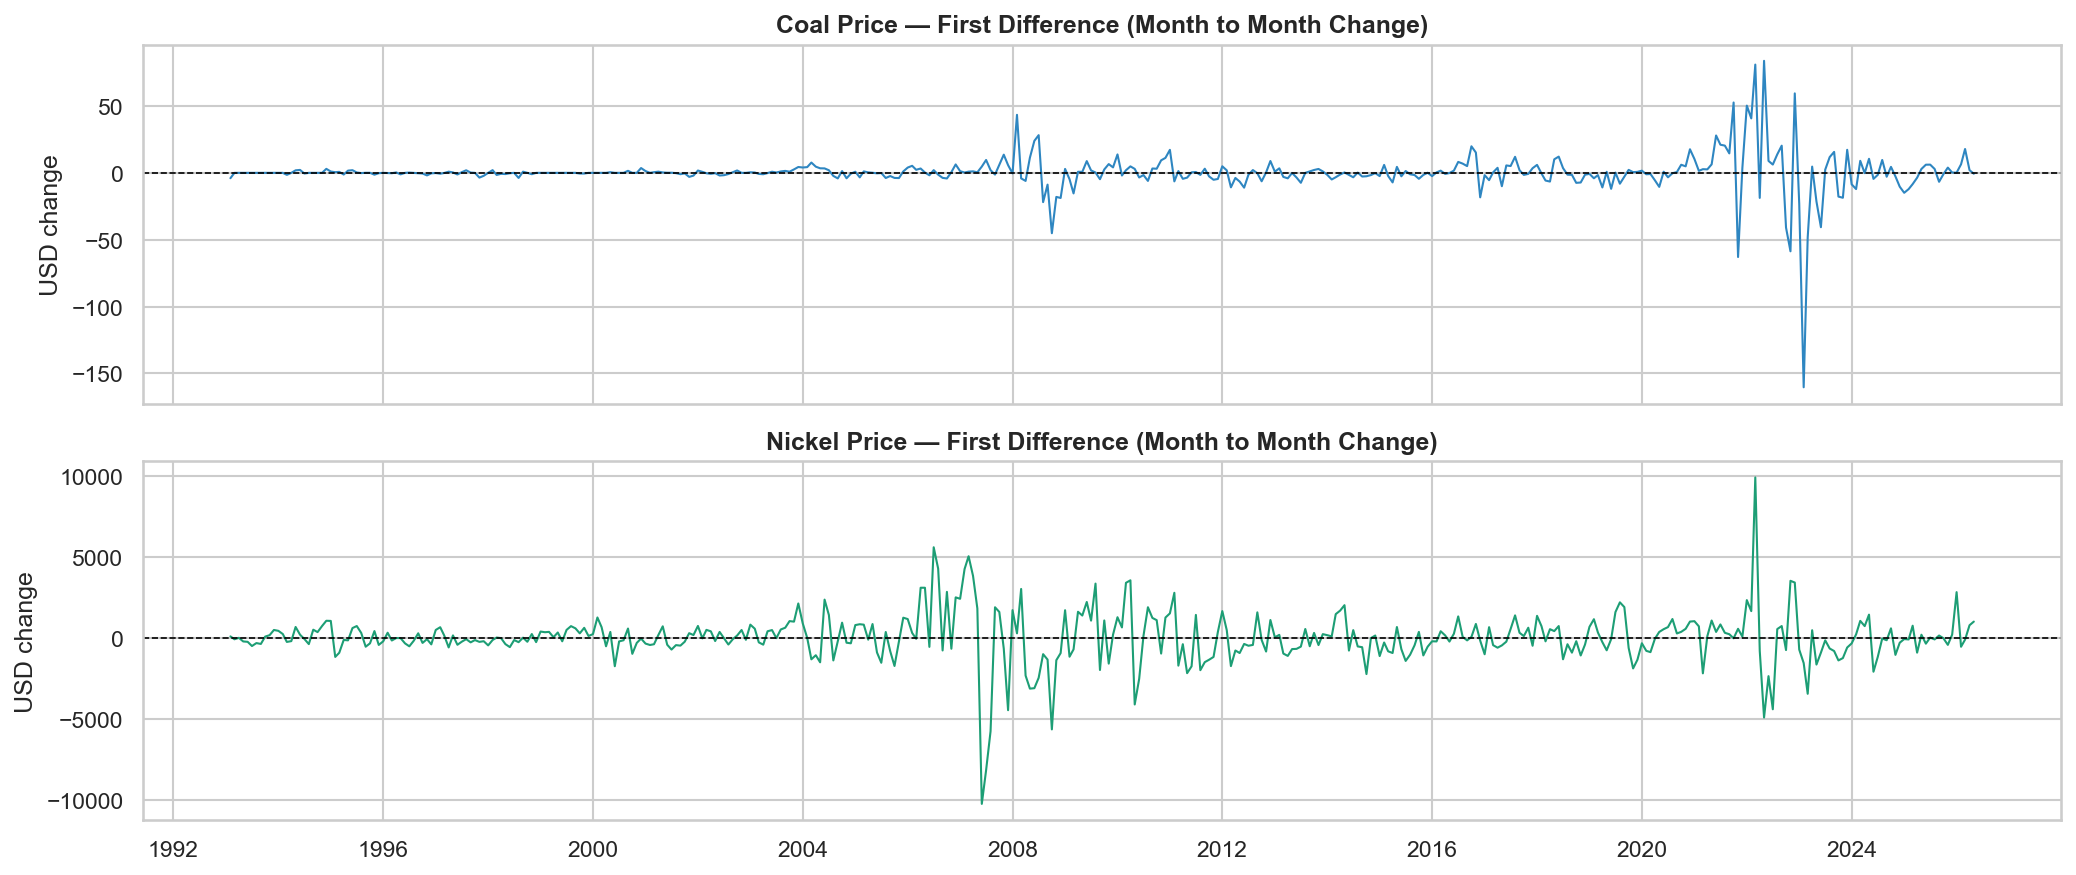

Chart 8 saved


In [4]:
# First difference = month to month change
# This removes the trend and makes the series stationary
df['coal_diff'] = df['coal_price_usd'].diff()
df['nickel_diff'] = df['nickel_price_usd'].diff()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df.index, df['coal_diff'], color='#2E86C1', linewidth=1)
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Coal Price — First Difference (Month to Month Change)', fontweight='bold')
ax1.set_ylabel('USD change')

ax2.plot(df.index, df['nickel_diff'], color='#1D9E75', linewidth=1)
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Nickel Price — First Difference (Month to Month Change)', fontweight='bold')
ax2.set_ylabel('USD change')

plt.tight_layout()
plt.savefig('../charts/08_differenced_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

## Chart 8. Month to Month Price Changes

Looking at this chart I immediately noticed how different the 
personalities of coal and nickel are.

Coal was essentially quiet from 1993 to 2003. The monthly changes 
were tiny, the line barely moves. I could see the moment the 
China boom started because the swings suddenly got bigger. But 
what really surprised me was the post-COVID period where coal 
swung by over $150 in a single month. To put that in perspective 
that's more than 3 times the entire price of coal back in the 
1990s happening in just 30 days. That kind of volatility can 
make or break a mining company depending on which side of a 
supply contract they're on.

Nickel's chart told a completely different story. Even back in 
the early 2000s nickel was already showing 5,000 dollar monthly swings. 
During the 2008 GFC I could see nickel dropped almost $10,000 
in a single month. That's an extraordinary number. This confirmed 
what I found in the EDA nickel is genuinely one of the most 
volatile industrial metals in the world and Indonesian nickel 
producers need strong risk management strategies to survive 
these kinds of swings.

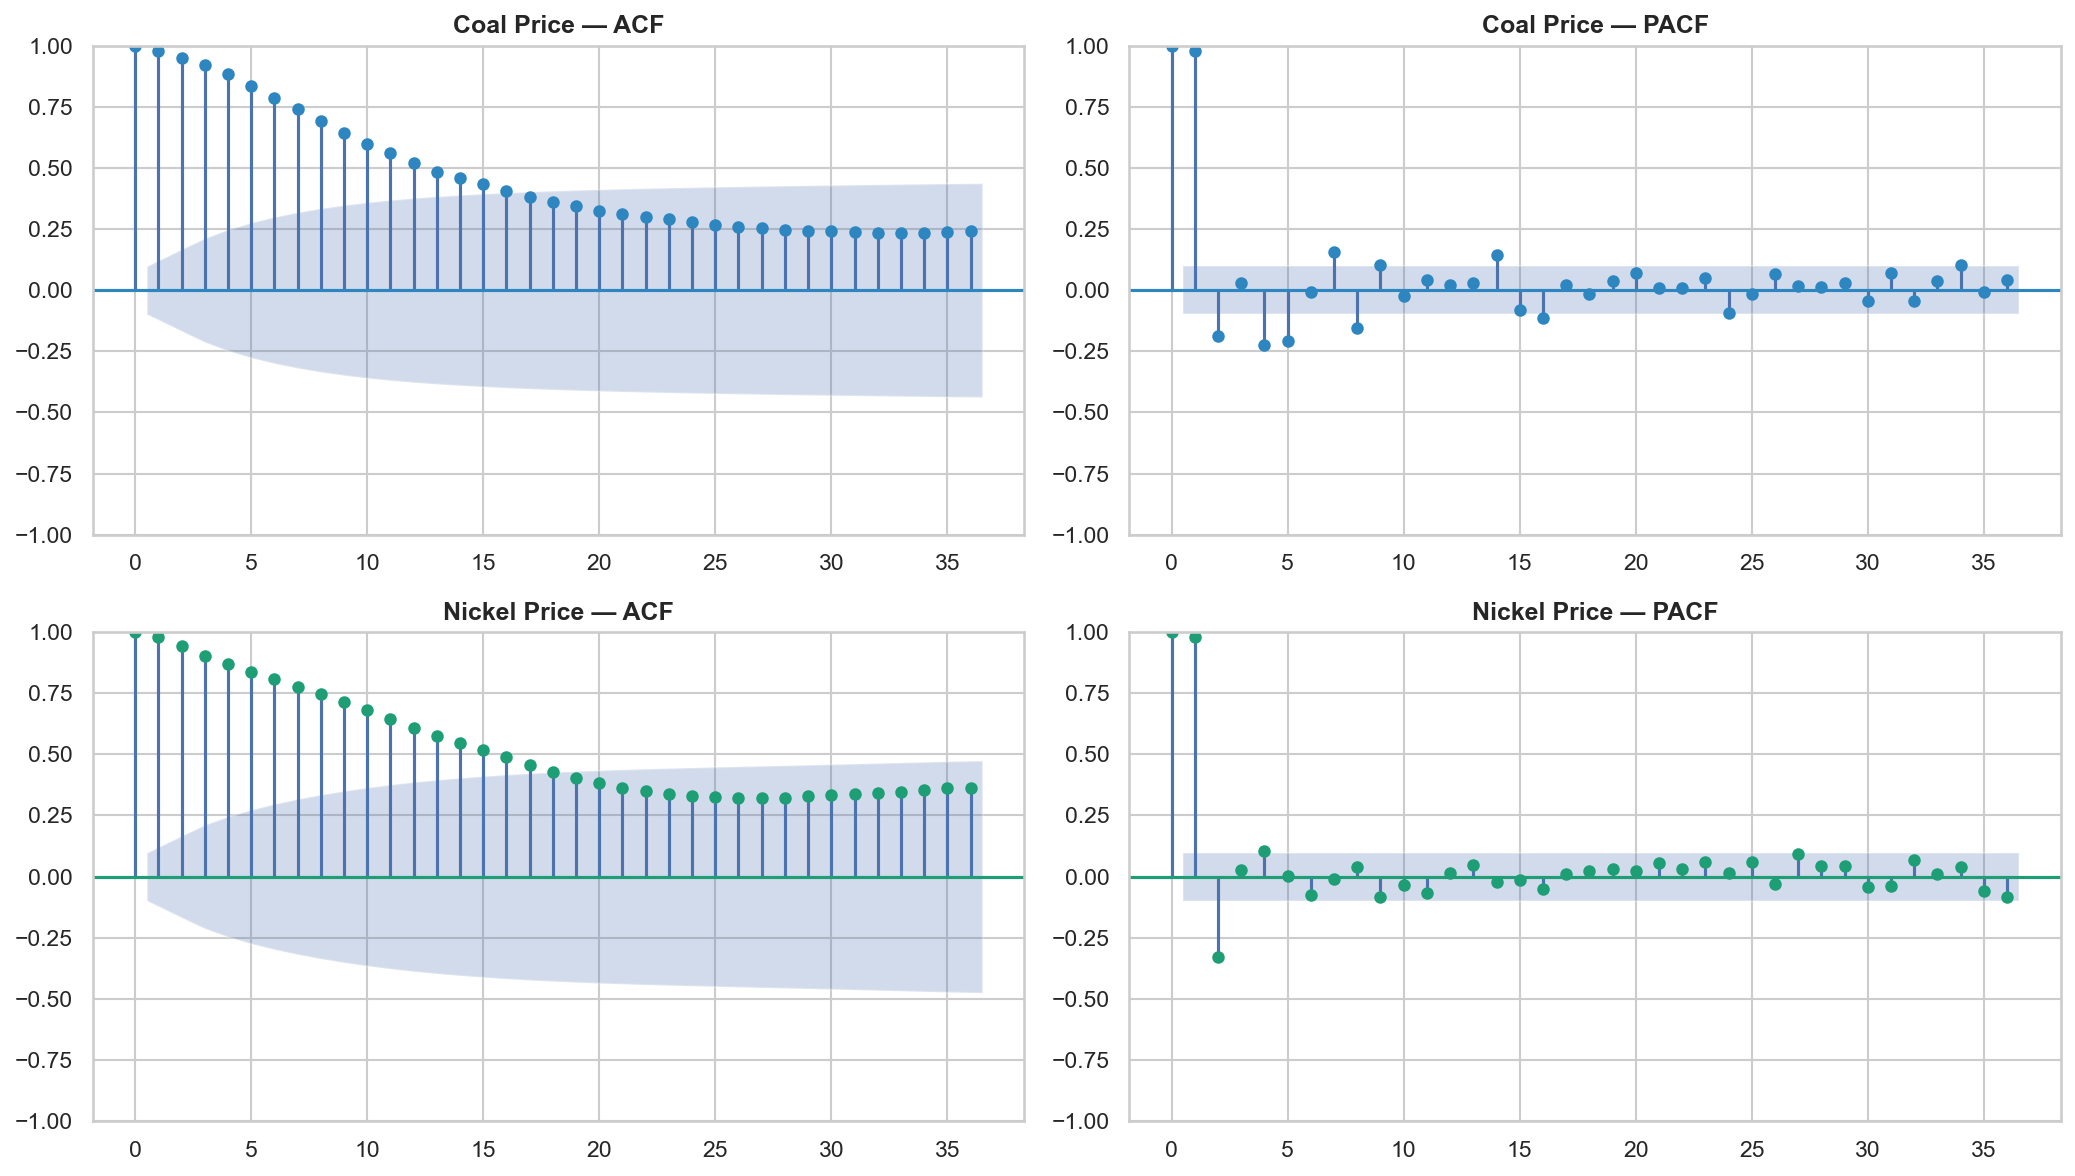

Chart 9 saved


In [5]:
# ACF = how correlated is today's price with past prices?
# PACF = what's the direct relationship with each lag?
# These plots tell us what parameters to use in our forecasting model

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df['coal_price_usd'].dropna(), lags=36, ax=axes[0,0], color='#2E86C1')
axes[0,0].set_title('Coal Price — ACF', fontweight='bold')

plot_pacf(df['coal_price_usd'].dropna(), lags=36, ax=axes[0,1], color='#2E86C1')
axes[0,1].set_title('Coal Price — PACF', fontweight='bold')

plot_acf(df['nickel_price_usd'].dropna(), lags=36, ax=axes[1,0], color='#1D9E75')
axes[1,0].set_title('Nickel Price — ACF', fontweight='bold')

plot_pacf(df['nickel_price_usd'].dropna(), lags=36, ax=axes[1,1], color='#1D9E75')
axes[1,1].set_title('Nickel Price — PACF', fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/09_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved")

## Chart 9. ACF and PACF Analysis

I ran these tests specifically to figure out how far back in 
history I need to look to make a good prediction about next 
month's price. The answer surprised me a little.

Looking at the ACF charts for both coal and nickel, the bars 
decline very slowly over 36 months and never really drop to zero. 
This confirmed what the ADF test already told me — both commodities 
have a very long memory. What happened 2 or 3 years ago still 
has some influence on today's price. That's the nature of 
commodity markets where supply infrastructure and long-term 
contracts create slow-moving momentum.

But when I looked at the PACF charts the story became much more 
specific. For both coal and nickel, only the first 1 or 2 bars 
stick outside the blue confidence band. Everything after that 
falls inside. What this told me is that once I account for 
last month's price, the additional months don't add much new 
information. The single most powerful predictor of next month's 
coal price is simply what coal cost last month.

This was a really useful finding because it told me exactly 
how to set up the forecasting model in notebook 5. I don't 
need to feed the model years of history. I mainly need 
the most recent 1 to 2 months as direct inputs.

In [6]:
df.to_csv('../data/commodity_timeseries.csv')
print("Saved with time series features")
print(f"Final columns: {df.columns.tolist()}")

Saved with time series features
Final columns: ['coal_price_usd', 'nickel_price_usd', 'usd_idr', 'coal_price_idr', 'nickel_price_idr', 'year', 'month', 'month_name', 'coal_mom_change', 'nickel_mom_change', 'coal_yoy_change', 'nickel_yoy_change', 'coal_ma3', 'coal_ma12', 'nickel_ma3', 'nickel_ma12', 'coal_volatility', 'nickel_volatility', 'coal_nickel_ratio', 'coal_above_ma12', 'nickel_above_ma12', 'market_period', 'coal_diff', 'nickel_diff']
